In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

sns.set(style='whitegrid', context='talk')

### helpers

In [3]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_trials(n_stim=20, boundaries=(0.25, 0.5, 0.75), tail_eps=0.15):
    # Build full factorial trial table: each stimulus x each boundary
    # 20 equidistant points strictly inside (0,1)
    stim_values = np.linspace(0, 1, n_stim + 2, dtype=np.float32)[1:-1]

    rows = []
    for b in boundaries:
        for i, stim in enumerate(stim_values):
            cls = float(stim > b)  # binary class relative to boundary
            tail_mask = float((stim <= tail_eps) or (stim >= (1 - tail_eps)))  # edge stimuli flag
            rows.append(
                {
                    'boundary': float(b),
                    'boundary_label': f'b={b:.2f}',
                    'stim': float(stim),
                    'stim_idx': int(i),
                    'class': cls,
                    'tail_mask': tail_mask,
                }
            )

    return pd.DataFrame(rows)


def split_train_test(df, test_frac=0.2, seed=0):
    # Create deterministic RNG for reproducible splits
    rng = np.random.default_rng(seed)
    test_idx = []

    # Stratify by boundary so each condition contributes test samples
    # independently (prevents one boundary from dominating the test set).
    for _, grp in df.groupby('boundary'):
        idx = grp.index.to_numpy()
        rng.shuffle(idx)  # randomize order within this boundary group

        # Per-boundary test count (at least 1 row from each boundary).
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx.extend(idx[:n_test])

    # Sort once for stable ordering; train is the complement of test indices.
    test_idx = np.array(sorted(test_idx))
    train_idx = df.index.difference(test_idx)

    # Return clean, reindexed dataframes for downstream tensor conversion.
    return (
        df.loc[train_idx].reset_index(drop=True),
        df.loc[test_idx].reset_index(drop=True),
    )


def df_to_tensors(df):
    # Convert dataframe columns into model input/target tensors
    X = torch.tensor(df[['stim', 'boundary']].values, dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values, dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values, dtype=torch.float32)
    y_bound = torch.tensor(df[['boundary']].values, dtype=torch.float32)
    y_tail = torch.tensor(df[['tail_mask']].values, dtype=torch.float32)
    return X, y_class, y_stim, y_bound, y_tail

### Generate data

In [19]:
# config
n_stim = 20
boundaries = (0.25, 0.5, 0.75)
n_nets = 30

# loss weights (descending priority)
class_wt = 1.0
stim_wt = 0.30
bound_wt = 0.0
tail_wt = 0.0

tail_eps = 0.15
use_train_test_split = True
test_frac = 0.20
base_seed = 20260302

# generate 60 unique trials
trials_df = make_trials(n_stim=n_stim, boundaries=boundaries, tail_eps=tail_eps)
assert len(trials_df) == 60

if use_train_test_split:
    train_df, test_df = split_train_test(trials_df, test_frac=test_frac, seed=base_seed)
else:
    train_df = trials_df.copy()
    test_df = trials_df.copy()

print(f'Total trials: {len(trials_df)} | Train: {len(train_df)} | Test: {len(test_df)}')
trials_df.head()

Total trials: 60 | Train: 48 | Test: 12


,boundary,boundary_label,stim,stim_idx,class,tail_mask
0,0.25,b=0.25,0.047619,0,0.0,1.0
1,0.25,b=0.25,0.095238,1,0.0,1.0
2,0.25,b=0.25,0.142857,2,0.0,1.0
3,0.25,b=0.25,0.190476,3,0.0,0.0
4,0.25,b=0.25,0.238095,4,0.0,0.0


### Organize data

In [20]:
# convert to tensors
X_train, y_class_train, y_stim_train, y_bound_train, y_tail_train = df_to_tensors(train_df)
X_test, y_class_test, y_stim_test, y_bound_test, y_tail_test = df_to_tensors(test_df)
X_full, y_class_full, y_stim_full, y_bound_full, y_tail_full = df_to_tensors(trials_df)

# class imbalance handling for BCE
pos_count = float(y_class_train.sum().item())
neg_count = float(len(y_class_train) - pos_count)
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], dtype=torch.float32)

# data loaders
batch_size = 48
train_ds = TensorDataset(X_train, y_class_train, y_stim_train, y_bound_train, y_tail_train)
test_ds = TensorDataset(X_test, y_class_test, y_stim_test, y_bound_test, y_tail_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f'pos_weight for BCE: {pos_weight.item():.3f}')
train_loader, test_loader

pos_weight for BCE: 1.087


(<torch.utils.data.dataloader.DataLoader at 0x7f5b7029cf90>,
 <torch.utils.data.dataloader.DataLoader at 0x7f5b68342750>)

### Create networks

In [21]:

# ── Architecture ──────────────────────────────────────────────────────────────
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 1-output boundary-classification network.

    Inputs : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden : 10 units, ReLU
    Output : sigmoid  →  response ∈ (0,1)
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(h))

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (output, hidden_activations) for neural analysis."""
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out, h


# ── Training / evaluation epoch ───────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, pos_weight=None):
    """
    Run one full pass over *loader*.
    Pass optimizer=None for evaluation (no gradient updates).

    Loss components (read from enclosing-scope config variables):
      class_wt  · BCE(pred, y_class)              ← primary classification
      stim_wt   · MSE(pred, y_stim)               ← proximity to stimulus value
      bound_wt  · MSE(pred, y_bound)              ← regulariser towards boundary
      tail_wt   · MSE(pred[tail], y_class[tail])  ← push extreme stim to 0 / 1

    Returns
    -------
    dict with keys: total, loss_class, loss_stim, loss_bound, loss_tail, acc
    """
    training = optimizer is not None
    model.train(training)
    ctx = torch.enable_grad() if training else torch.no_grad()

    # Accumulators for weighted sums; will be divided by total n at the end.
    totals = dict(total=0.0, loss_class=0.0, loss_stim=0.0,
                  loss_bound=0.0, loss_tail=0.0, correct=0, n=0)

    with ctx:
        for X, y_class_b, y_stim_b, y_bound_b, y_tail_b in loader:
            pred = model(X)                              # [batch, 1] — sigmoid output

            # ── Loss 1: Weighted binary cross-entropy (primary objective) ──────
            # Up-weight positive (class=1) examples to correct for class imbalance.
            # If no pos_weight provided, fall back to standard unweighted BCE.
            if pos_weight is not None:
                # Assign pos_weight to positive examples, 1.0 to negatives.
                wt = torch.where(y_class_b == 1,
                                 pos_weight.expand_as(y_class_b),
                                 torch.ones_like(y_class_b))
                class_loss = F.binary_cross_entropy(pred, y_class_b, weight=wt) * class_wt
            else:
                class_loss = F.binary_cross_entropy(pred, y_class_b) * class_wt

            # ── Loss 2: MSE towards raw stimulus value ─────────────────────────
            mse_loss  = F.mse_loss(pred, y_stim_b)  * stim_wt

            # ── Loss 3: MSE towards boundary value ────────────────────────────
            # Soft regulariser pulling ambiguous (near-boundary) responses toward
            # the boundary itself, preventing over-confident outputs in that region.
            bound_loss = F.mse_loss(pred, y_bound_b) * bound_wt

            # ── Loss 4: Tail anchor — extreme stimuli should map to 0 or 1 ─────
            # Only computed when at least one tail trial is present in the batch.
            # y_tail_b is 1 for edge stimuli (stim <= tail_eps or >= 1-tail_eps).
            tail_trials = y_tail_b.squeeze(1).bool()
            if tail_trials.any():
                # For tail trials, push response toward the categorical label (0/1).
                tail_loss = F.mse_loss(pred[tail_trials], y_class_b[tail_trials]) * tail_wt
            else:
                # No tail trials in this batch; contribute zero loss.
                tail_loss = torch.tensor(0.0)

            # ── Combined loss ─────────────────────────────────────────────────
            loss = class_loss + mse_loss + bound_loss + tail_loss

            if training:
                # Standard PyTorch training step: clear old gradients, backprop,
                # then update weights using the Adam optimizer.
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # ── Accumulate batch statistics (weighted by batch size) ───────────
            # Multiplying by batch_n so the final per-sample average is correct
            # even when the last batch is smaller than the others.
            batch_n = X.size(0)
            totals['total']      += loss.item()       * batch_n
            totals['loss_class'] += class_loss.item() * batch_n
            totals['loss_stim']  += mse_loss.item()   * batch_n
            totals['loss_bound'] += bound_loss.item() * batch_n
            totals['loss_tail']  += tail_loss.item()  * batch_n
            # Count correctly classified samples (threshold at 0.5).
            totals['correct']    += ((pred >= 0.5).float() == y_class_b).sum().item()
            totals['n']          += batch_n

    # ── Normalise accumulators to per-sample averages ─────────────────────────
    # Pop 'n' and 'correct' before dividing so they don't get averaged themselves.
    n       = max(totals.pop('n'), 1)       # guard against empty loader
    correct = totals.pop('correct')
    # Merge the per-sample loss dict with the scalar accuracy value.
    return {k: v / n for k, v in totals.items()} | {'acc': correct / n}


# ── Full-dataset inference with hidden activations ────────────────────────────
def evaluate_model_on_df(model, df, pos_weight=None):
    """
    Run inference on every row of *df* in one shot (no shuffling).

    Returns
    -------
    pred_df : copy of df with 'resp' and 'class_pred' columns added
    hidden  : np.ndarray  [n_trials, hidden_dim]  hidden-layer activations
    metrics : dict — same keys as run_epoch's return value
    """
    model.eval()
    X, y_class, y_stim, y_bound, y_tail = df_to_tensors(df)

    with torch.no_grad():
        # forward_with_hidden returns both the sigmoid output and the
        # post-ReLU hidden activations needed for representational analysis.
        out, h = model.forward_with_hidden(X)    # [n,1], [n, hidden_dim]

    resp   = out.squeeze(1).numpy()              # [n]
    hidden = h.numpy()                           # [n, 10]

    pred_df = df.copy()
    pred_df['resp']       = resp
    pred_df['class_pred'] = (resp >= 0.5).astype(float)

    # Recompute scalar loss/accuracy metrics using run_epoch on a single batch
    # that covers the entire dataset, ensuring metrics are consistent with training.
    ds      = TensorDataset(X, y_class, y_stim, y_bound, y_tail)
    loader  = DataLoader(ds, batch_size=len(df), shuffle=False)
    metrics = run_epoch(model, loader, optimizer=None, pos_weight=pos_weight)

    return pred_df, hidden, metrics


print('BoundaryNet, run_epoch, and evaluate_model_on_df defined.')
BoundaryNet()


BoundaryNet, run_epoch, and evaluate_model_on_df defined.


BoundaryNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)

### Train & Test

In [22]:
# training setup
max_epochs = 800   # hard cap — training always stops here even without convergence
min_epochs = 30    # burn-in period: convergence is not checked before this epoch
conv_target = 0.90 # rolling-window train accuracy that triggers early stopping
conv_window = 20   # number of recent epochs averaged to assess convergence
lr = 1e-2

network_results = []

for net_idx in range(n_nets):
    # Each network gets a unique but deterministic seed derived from the base seed,
    # so the ensemble is reproducible while each member is independently initialized.
    seed = base_seed + net_idx
    set_seed(seed)

    # Fresh model and optimizer for every network in the ensemble.
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)

    network_epochs = []       # per-epoch stats for this network
    converged = False  # flag: did this network meet the early-stopping criterion?

    for epoch in range(max_epochs):
        # --- Training pass: gradients are computed and weights are updated. ---
        train_stats = run_epoch(model, train_loader, optimizer=optimizer, pos_weight=pos_weight)

        # --- Evaluation pass: no gradient updates, held-out test set only. ---
        test_stats = run_epoch(model, test_loader, optimizer=None, pos_weight=pos_weight)

        # Store both train and test stats for this epoch with prefixed keys.
        row = {
            'net_idx': net_idx,
            'seed': seed,
            'epoch': epoch,
            **{f"train_{k}": v for k, v in train_stats.items()},
            **{f"test_{k}": v for k, v in test_stats.items()},
        }
        network_epochs.append(row)

        # Early stopping check: only after burn-in and once enough epochs exists.
        if epoch >= min_epochs and len(network_epochs) >= conv_window:
            # Average train accuracy over the last `conv_window` epochs.
            recent_train_acc = np.mean([h['train_acc'] for h in network_epochs[-conv_window:]])
            if recent_train_acc >= conv_target:
                converged = True
                break  # exit the epoch loop; model is considered trained

    network_epochs_df = pd.DataFrame(network_epochs)

    # Final inference on every trial (including training trials) to get
    # a complete picture of the learned response function and hidden activations.
    full_pred_df, hidden_full, full_metrics = evaluate_model_on_df(model, trials_df, pos_weight=pos_weight)
    test_pred_df, hidden_test, test_metrics = evaluate_model_on_df(model, test_df, pos_weight=pos_weight)

    # Bundle everything for this network into a single dict so it can be accessed
    # uniformly when aggregating results across the ensemble.
    network_results.append(
        {
            'net_idx': net_idx,
            'seed': seed,
            'model': model,
            'epoch_results': network_epochs_df,
            'converged': converged,
            'epochs_ran': int(network_epochs_df['epoch'].max() + 1),
            'full_pred_df': full_pred_df,
            'test_pred_df': test_pred_df,
            'hidden_full': hidden_full,   # shape: [60, hidden_dim] — used for PCA
            'hidden_test': hidden_test,
            'full_metrics': full_metrics,
            'test_metrics': test_metrics,
        }
    )

nets_summarized_df = pd.DataFrame(
    {
        'net_idx': [net['net_idx'] for net in network_results],
        'seed': [net['seed'] for net in network_results],
        'converged': [net['converged'] for net in network_results],
        'epochs_ran': [net['epochs_ran'] for net in network_results],
        'test_acc': [net['test_metrics']['acc'] for net in network_results],
        'test_total_loss': [net['test_metrics']['total'] for net in network_results],
    }
)

nets_summarized_df.describe(include='all')

,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
count,30.000000,3.000000e+01,30,30.000000,30.000000,30.000000
unique,NaN,NaN,1,NaN,NaN,NaN
top,NaN,NaN,True,NaN,NaN,NaN
freq,NaN,NaN,30,NaN,NaN,NaN
mean,14.500000,2.026032e+07,NaN,54.100000,0.977778,0.489848
std,8.803408,8.803408e+00,NaN,22.167622,0.048608,0.120297
min,0.000000,2.026030e+07,NaN,31.000000,0.833333,0.254138
25%,7.250000,2.026031e+07,NaN,34.500000,1.000000,0.383269
50%,14.500000,2.026032e+07,NaN,50.000000,1.000000,0.521965
75%,21.750000,2.026032e+07,NaN,72.500000,1.000000,0.579054


### Check results

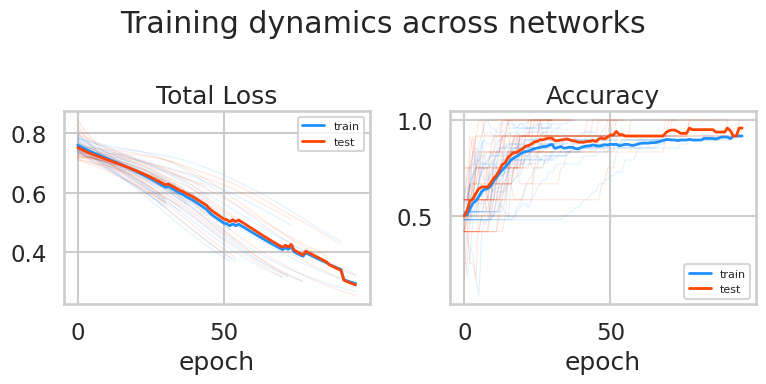

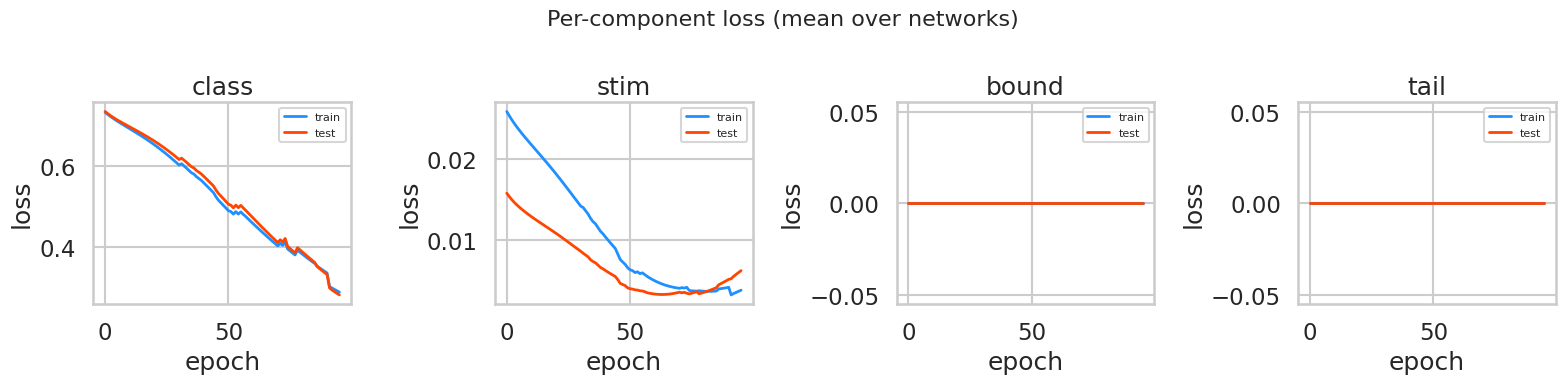

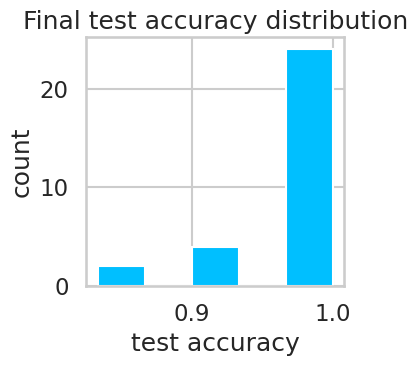

In [23]:
# ── Concatenate all per-epoch records across networks ─────────────────────────
all_epochs = pd.concat(
    [r['epoch_results'] for r in network_results],
    ignore_index=True,
)

# ── 1. Total Loss & Accuracy over epochs (train vs test) ─────────────────────
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs = axs.flatten()

for ax, (title, train_col, test_col) in zip(axs, [
    ('Total Loss', 'train_total', 'test_total'),
    ('Accuracy',   'train_acc',   'test_acc'),
]):
    # thin semi-transparent traces per network
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)

    # bold mean across networks
    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=2, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=2, label='test')

    ax.set(title=title, xlabel='epoch', ylabel='')
    ax.legend(fontsize=8)

plt.suptitle('Training dynamics across networks')
plt.tight_layout()
plt.show()

# ── 2. Per-component loss (mean over networks) ───────────────────────────────
loss_comps = ['loss_class', 'loss_stim', 'loss_bound', 'loss_tail']

fig, axs = plt.subplots(1, len(loss_comps), figsize=(4 * len(loss_comps), 4))
axs = axs.flatten()

for ax, comp in zip(axs, loss_comps):
    tr_col, te_col = f'train_{comp}', f'test_{comp}'
    mn = all_epochs.groupby('epoch')[[tr_col, te_col]].mean()
    ax.plot(mn.index, mn[tr_col], color='dodgerblue', linewidth=2, label='train')
    ax.plot(mn.index, mn[te_col], color='orangered',  linewidth=2, label='test')
    ax.set(title=comp.replace('loss_', ''), xlabel='epoch', ylabel='loss')
    ax.legend(fontsize=8)

plt.suptitle('Per-component loss (mean over networks)', fontsize=16)
plt.tight_layout()
plt.show()


# ── 3. Final test accuracy distribution ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.hist(nets_summarized_df['test_acc'], bins=5, color='deepskyblue', edgecolor='white')
mean_acc = nets_summarized_df['test_acc'].mean()
ax.set(xlabel='test accuracy', ylabel='count', title='Final test accuracy distribution')
plt.tight_layout()
plt.show()



In [24]:
print('Convergence rate:', nets_summarized_df['converged'].mean())
print('Mean epochs run:',  nets_summarized_df['epochs_ran'].mean())
print('Mean test accuracy:', nets_summarized_df['test_acc'].mean())
print('Std  test accuracy:', nets_summarized_df['test_acc'].std())

nets_summarized_df.head()


Convergence rate: 1.0
Mean epochs run: 54.1
Mean test accuracy: 0.9777777777777779
Std  test accuracy: 0.04860769008213957


,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
0,0,20260302,True,92,1.000000,0.306767
1,1,20260303,True,46,0.833333,0.580739
2,2,20260304,True,31,0.833333,0.639318
3,3,20260305,True,86,1.000000,0.387362
4,4,20260306,True,38,1.000000,0.572108


### Behavior

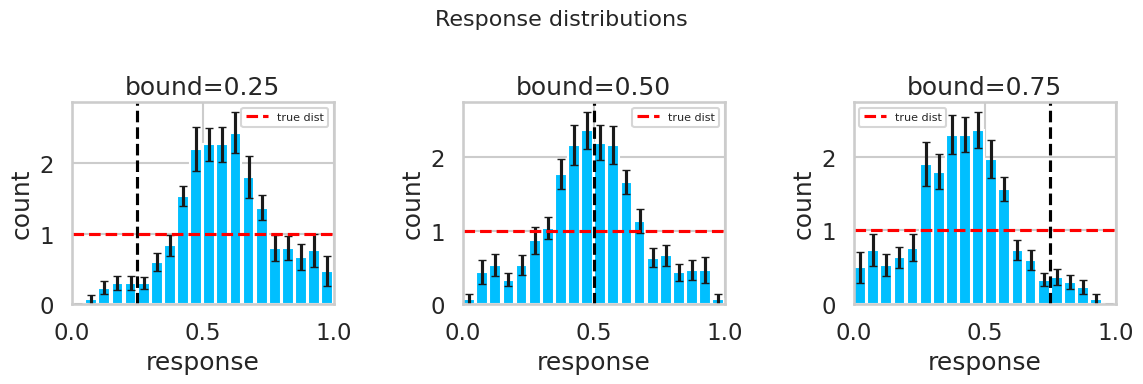

In [25]:
# collect all network predictions on full 60-trial grid
beh_df = pd.concat(
    [network_result['full_pred_df'].assign(net_idx=network_result['net_idx']) for network_result in network_results],
    ignore_index=True,
)

# shared config
b_colors = {0.25: 'orangered', 0.50: 'gray', 0.75: 'dodgerblue'}
n_bins = 20

# ── Plot 1: Response histogram (1×3, per boundary) ───────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0

for bound in boundaries:
    cond_df = beh_df[beh_df['boundary'] == bound]

    resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'):
        counts, _ = np.histogram(net_df['resp'], bins=n_bins, range=(0, 1))
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_cts = resp_cts.mean(axis=0)
    sem_cts  = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])
    bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

    axs[ax].bar(bin_centers, mean_cts, width=1/n_bins * 0.9, color='deepskyblue', yerr=sem_cts, capsize=3)
    axs[ax].axvline(bound, color='black', linestyle='--')
    axs[ax].axhline(n_stim / n_bins, color='red', linestyle='--', label='true dist')
    axs[ax].set(xlabel='response', ylabel='count', title=f'bound={bound:.2f}', xlim=(0, 1))
    axs[ax].legend(fontsize=8)
    ax += 1

plt.suptitle('Response distributions', fontsize=16)
plt.tight_layout()
plt.show()


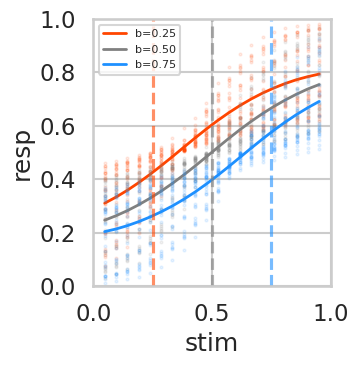

In [11]:
# ── Plot 2: Raw stim vs resp ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim'], sub['resp'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim')['resp'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])

for b in boundaries:
    ax.axvline(b, color=b_colors[b], linestyle='--', alpha=0.6)

ax.set(xlabel='stim', ylabel='resp', xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


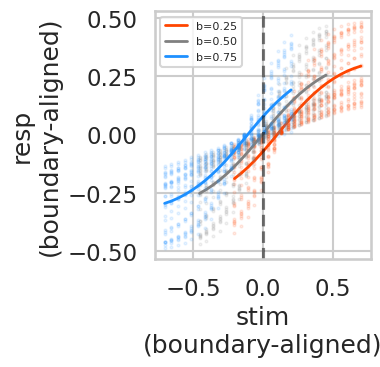

In [12]:
# ── Plot 3: Boundary-aligned stim vs resp ─────────────────────────────────────
beh_df['stim_aligned'] = beh_df['stim'] - beh_df['boundary']
beh_df['resp_aligned'] = beh_df['resp'] - 0.5

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim_aligned'], sub['resp_aligned'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set(xlabel='stim\n(boundary-aligned)', ylabel='resp\n(boundary-aligned)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


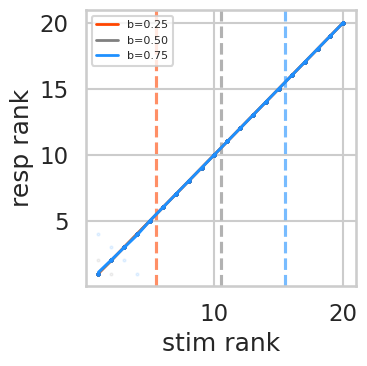

In [13]:
# ── Plot 4: Stim rank vs resp rank ────────────────────────────────────────────
beh_df['stim_rank'] = beh_df.groupby(['net_idx', 'boundary'])['stim'].rank()
beh_df['resp_rank'] = beh_df.groupby(['net_idx', 'boundary'])['resp'].rank()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim_rank'], sub['resp_rank'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim_rank')['resp_rank'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])
    n_below = int((trials_df[trials_df['boundary'] == b]['stim'] < b).sum())
    ax.axvline(n_below + 0.5, color=b_colors[b], linestyle='--', alpha=0.6)

ax.set(xlabel='stim rank', ylabel='resp rank')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Neural

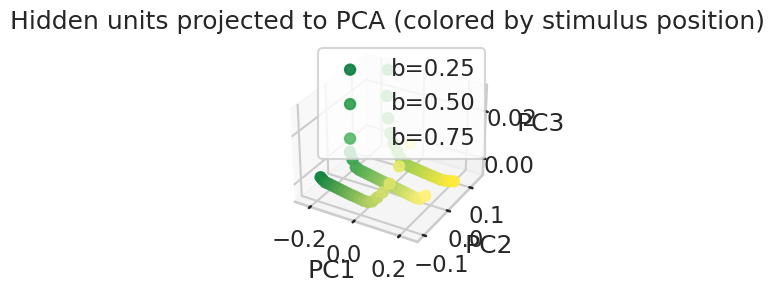

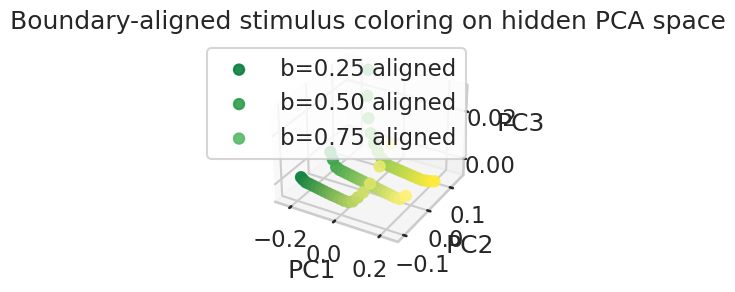

,boundary,bound_pos
0,0.25,0.047619
1,0.50,0.047619
2,0.75,0.047619


In [14]:
# average hidden activations across networks for each of the 60 trials
hidden_stack = np.stack([r['hidden_full'] for r in network_results], axis=0)  # [n_nets, 60, 10]
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = trials_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = {
    0.25: LinearSegmentedColormap.from_list('gy_025', ['#0a7f3f', '#f3ef6d']),
    0.50: LinearSegmentedColormap.from_list('gy_050', ['#2c9e4b', '#fff176']),
    0.75: LinearSegmentedColormap.from_list('gy_075', ['#59b96a', '#ffeb3b']),
}

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for b in boundaries:
    sub = pca_df[pca_df['boundary'] == b].sort_values('stim')
    norm = Normalize(vmin=sub['stim'].min(), vmax=sub['stim'].max())
    colors = cond_cmaps[b](norm(sub['stim'].values))

    ax.scatter(sub['PC1'], sub['PC2'], sub['PC3'], c=colors, s=55, alpha=0.9, label=f'b={b:.2f}')

ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# boundary-align stimulus positions
# bound_pos = Euclidean distance between the two stimuli that flank each boundary.
bound_pos = {}
for b in boundaries:
    stim_vals = np.sort(pca_df.loc[pca_df['boundary'] == b, 'stim'].unique())
    lower = stim_vals[stim_vals < b].max()
    upper = stim_vals[stim_vals > b].min()
    bound_pos[b] = float(np.linalg.norm(np.array([upper - lower])))

pca_df['stim_aligned'] = pca_df['stim'] - pca_df['boundary'].map(bound_pos)

# plot 2: re-plot with aligned stimulus-position coloring
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for b in boundaries:
    sub = pca_df[pca_df['boundary'] == b].sort_values('stim_aligned')
    norm = Normalize(vmin=sub['stim_aligned'].min(), vmax=sub['stim_aligned'].max())
    colors = cond_cmaps[b](norm(sub['stim_aligned'].values))

    ax.scatter(sub['PC1'], sub['PC2'], sub['PC3'], c=colors, s=55, alpha=0.9, label=f'b={b:.2f} aligned')

ax.set_title('Boundary-aligned stimulus coloring on hidden PCA space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

pd.DataFrame({'boundary': list(bound_pos.keys()), 'bound_pos': list(bound_pos.values())})
